In [136]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd

from obspy import read

import matplotlib.pyplot as plt

In [137]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [138]:
class SeismicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SeismicCNN().to(device)
print(model)

SeismicCNN(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_f

In [139]:
torch.save(
    model.state_dict(),
    r"D:\Seismic_Monitoring_AI\notebook\best_seismic_model.pth"
)

In [140]:
model = SeismicCNN().to(device)

model.load_state_dict(
    torch.load(
        r"D:\Seismic_Monitoring_AI\models\best_seismic_model_v3.pth",
        map_location=device
    )
)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


C:\Users\RITESH KUMAR\AppData\Local\Temp\ipykernel_27776\1907752201.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


In [142]:
LABEL_MAP = {
    0: "Noise",
    1: "Avalanche",
    2: "Earthquake"
}

In [143]:
def predict_window(window):

    # same preprocessing used during training

    window = (
        window - window.mean()
    ) / (
        window.std() + 1e-8
    )

    window = torch.tensor(
        window,
        dtype=torch.float32
    )

    # (2000,) -> (1,1,2000)

    window = window.unsqueeze(0)
    window = window.unsqueeze(0)

    window = window.to(device)

    with torch.no_grad():

        outputs = model(window)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        pred = torch.argmax(
            probs,
            dim=1
        )

    return (
        LABEL_MAP[pred.item()],
        probs.cpu().numpy()[0]
    )

In [144]:
df = pd.read_csv(
    r"D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\labels.csv"
)

print(df.shape)

df.head()

(926, 9)


,Unnamed: 0,Event_id,starttime,initial_time,end_time,duration,label,av_score,eq_score
0,0,20210113_0459,2021-01-13T04:59:00.000000Z,14786.193554,51642.513601,184.281600,0,0.0,0.0
1,1,20210113_0829,2021-01-13T08:29:00.000000Z,10770.965059,19390.682744,43.098588,0,0.0,0.0
2,2,20210113_0900,2021-01-13T09:00:00.000000Z,218009.166918,229322.546380,56.566897,0,0.0,0.0
3,3,20210113_0942,2021-01-13T09:42:00.000000Z,16191.582307,32353.552966,80.809853,0,0.0,0.0
4,4,20210113_1215,2021-01-13T12:15:00.000000Z,17727.639386,25223.046069,37.477033,0,0.5,0.0


In [145]:
import os

DATA_ROOT = r"D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data"

def find_file(event_id, station="CS"):

    seasons = [
        "season_2020_21",
        "season_2021_22"
    ]

    for season in seasons:

        folder = os.path.join(
            DATA_ROOT,
            season,
            station
        )

        for file in os.listdir(folder):

            if event_id in file:

                return os.path.join(
                    folder,
                    file
                )

    return None

In [146]:
row = df.iloc[0]

event_id = row["Event_id"]

print(event_id)

file_path = find_file(
    event_id,
    station="CS"
)

print(file_path)

20210113_0459
D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2020_21\CS\DSMA.CS.EHZ_20210113_0459-20210113_0505.mseed


In [147]:
WINDOW_SIZE = 2000

def extract_window(
    signal,
    start_pick,
    end_pick,
    window_size=2000
):

    center = int(
        (start_pick + end_pick) / 2
    )

    left = center - window_size // 2

    right = center + window_size // 2

    if left < 0:
        left = 0
        right = window_size

    if right > len(signal):
        right = len(signal)
        left = right - window_size

    return signal[left:right]

In [148]:
tr = read(file_path)[0]

signal = tr.data.astype(np.float32)

start_pick = int(
    row["initial_time"]
)

end_pick = int(
    row["end_time"]
)

window = extract_window(
    signal,
    start_pick,
    end_pick,
    WINDOW_SIZE
)

print(window.shape)

(2000,)


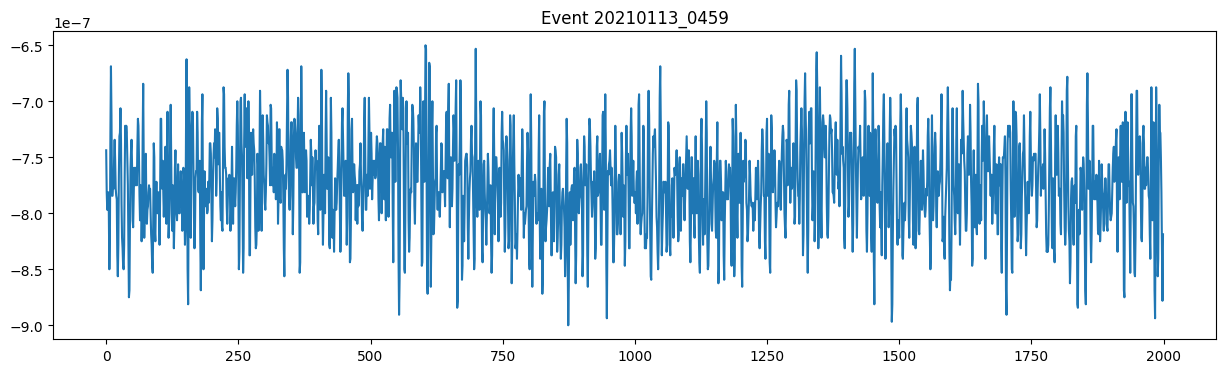

In [149]:
plt.figure(figsize=(15,4))

plt.plot(window)

plt.title(
    f"Event {event_id}"
)

plt.show()

In [150]:
label, probs = predict_window(
    window
)

print("Prediction:", label)

print("Probabilities:")

for i, p in enumerate(probs):

    print(
        LABEL_MAP[i],
        round(float(p),4)
    )

Prediction: Noise
Probabilities:
Noise 0.9454
Avalanche 0.004
Earthquake 0.0506


In [151]:
print("Prediction:", label)
print(probs)
print("Actual Label:", row["label"])

Prediction: Noise
[0.9453886  0.00401314 0.05059832]
Actual Label: 0


In [152]:
def detect_events(
    signal,
    threshold_multiplier=3,
    smooth_window=400,
    min_duration=400
):

    energy = signal**2

    kernel = np.ones(
        smooth_window
    ) / smooth_window

    smoothed = np.convolve(
        energy,
        kernel,
        mode="same"
    )

    threshold = (
        smoothed.mean()
        +
        threshold_multiplier *
        smoothed.std()
    )

    mask = smoothed > threshold

    events = []

    start = None

    for i,val in enumerate(mask):

        if val and start is None:

            start = i

        elif not val and start is not None:

            if i-start > min_duration:

                events.append(
                    (start,i)
                )

            start = None

    return events, smoothed, threshold

In [153]:
events = detect_events(
    signal,
    threshold_multiplier=4
)

print(
    "Number of detected events:",
    len(events)
)

print(events[:10])

Number of detected events: 3
([], array([2.95058201e-13, 2.96584080e-13, 2.98109959e-13, ...,
       2.98468554e-13, 2.96779857e-13, 2.95326342e-13], shape=(72001,)), np.float64(6.755084621646767e-13))


In [154]:
events, smoothed, threshold = detect_events(
    signal
)

print(events)
print("Detected:", len(events))

[]
Detected: 0


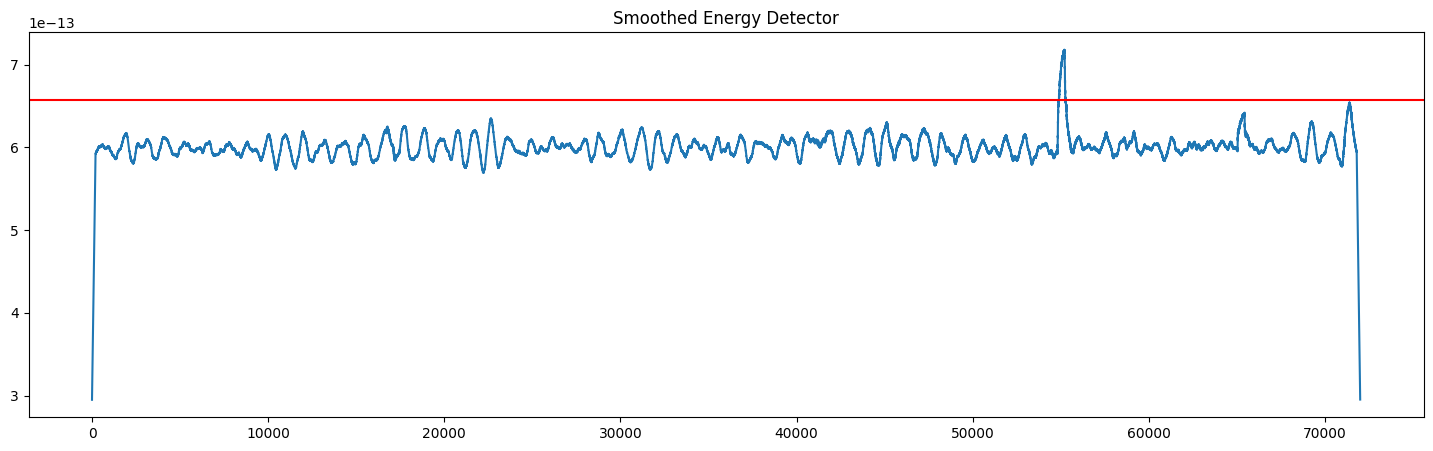

In [155]:
plt.figure(figsize=(18,5))

plt.plot(smoothed)

plt.axhline(
    threshold,
    color="red"
)

plt.title(
    "Smoothed Energy Detector"
)

plt.show()

In [156]:
from scipy.signal import spectrogram

def plot_spectrogram(signal, fs=200):

    # remove mean first
    signal = signal - np.mean(signal)

    # normalize
    signal = signal / (np.std(signal) + 1e-8)

    f, t, Sxx = spectrogram(
        signal,
        fs=fs,
        nperseg=256,
        noverlap=128
    )

    Sxx_db = 10 * np.log10(Sxx + 1e-12)

    plt.figure(figsize=(10,5))
    plt.pcolormesh(t, f, Sxx_db, shading='gouraud', cmap='viridis')
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")
    plt.title("Improved Spectrogram")
    plt.colorbar(label="Power (dB)")
    plt.ylim(0, 80)
    plt.tight_layout()
    plt.show()

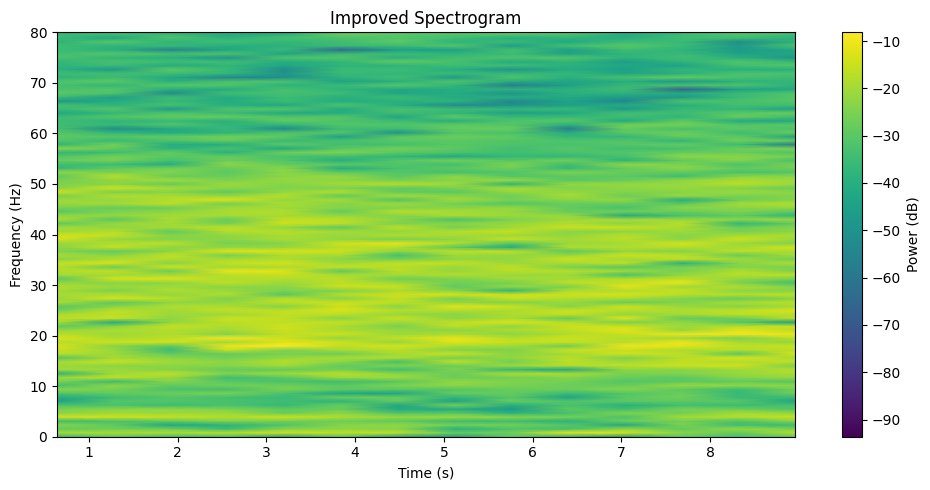

In [157]:
plot_spectrogram(window)

In [158]:
def preprocess_window(signal, window_size=2000):

    signal = signal - np.mean(signal)
    signal = signal / (np.std(signal) + 1e-8)

    if len(signal) > window_size:
        signal = signal[:window_size]
    elif len(signal) < window_size:
        signal = np.pad(signal, (0, window_size - len(signal)))

    return signal

In [159]:
##clean_window = preprocess_window(window)
##label, probs = predict_window(clean_window)
label, probs = predict_window(window)

print("Prediction:", label)
for i, p in enumerate(probs):
    print(LABEL_MAP[i], round(float(p), 4))

Prediction: Noise
Noise 0.9454
Avalanche 0.004
Earthquake 0.0506


In [160]:
def analyze_event(event_id, station="CS"):

    file_path = find_file(event_id, station)

    if file_path is None:
        print("File not found")
        return None

    tr = read(file_path)[0]
    signal = tr.data.astype(np.float32)

    start_pick = int(df[df["Event_id"] == event_id].iloc[0]["initial_time"])
    end_pick = int(df[df["Event_id"] == event_id].iloc[0]["end_time"])

    window = extract_window(
        signal,
        start_pick,
        end_pick,
        WINDOW_SIZE
    )

    window = preprocess_window(window)

    label, probs = predict_window(window)

    print("Event ID:", event_id)
    print("File:", file_path)
    print("Prediction:", label)
    print("Probabilities:")
    for i, p in enumerate(probs):
        print(LABEL_MAP[i], round(float(p), 4))

    plt.figure(figsize=(15,4))
    plt.plot(window)
    plt.title(f"Waveform: {event_id}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.show()

    plot_spectrogram(window)

    return label, probs

Event ID: 20210113_0459
File: D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2020_21\CS\DSMA.CS.EHZ_20210113_0459-20210113_0505.mseed
Prediction: Noise
Probabilities:
Noise 0.783
Avalanche 0.0369
Earthquake 0.1801


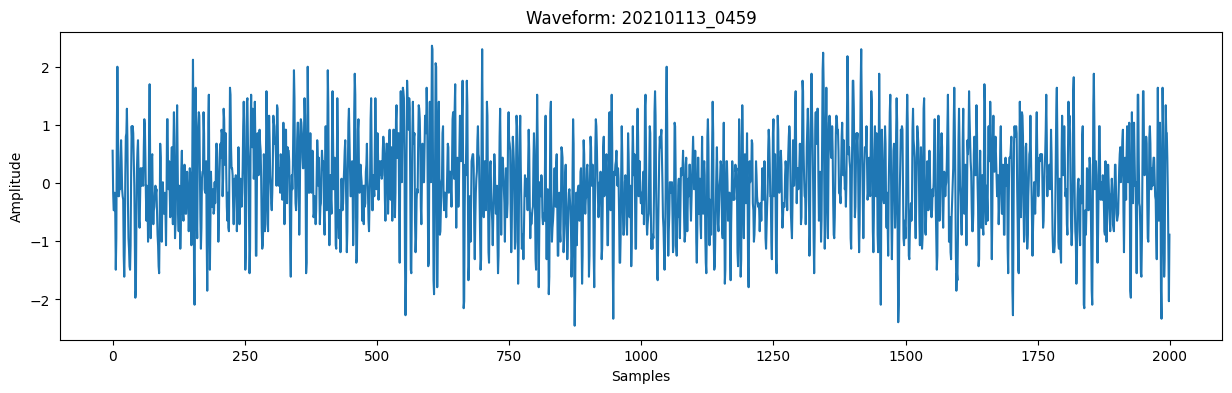

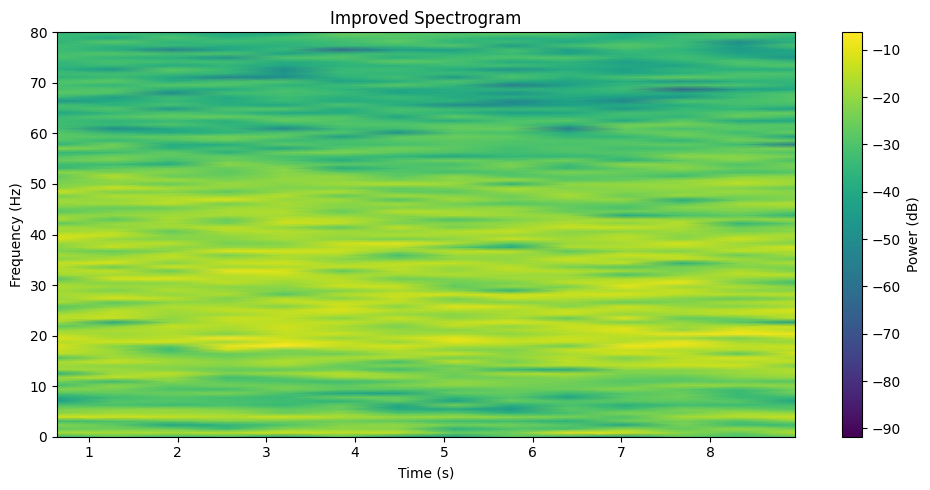

('Noise', array([0.78299046, 0.03688158, 0.180128  ], dtype=float32))

In [161]:
analyze_event("20210113_0459", station="CS")

In [162]:
def analyze_multiple_events(
    event_ids,
    station="CS"
):

    results = []

    for event_id in event_ids:

        try:

            file_path = find_file(
                event_id,
                station
            )

            tr = read(file_path)[0]

            signal = tr.data.astype(
                np.float32
            )

            row = df[
                df["Event_id"] == event_id
            ].iloc[0]

            start_pick = int(
                row["initial_time"]
            )

            end_pick = int(
                row["end_time"]
            )

            window = extract_window(
                signal,
                start_pick,
                end_pick,
                WINDOW_SIZE
            )

            window = preprocess_window(
                window
            )

            pred, probs = predict_window(
                window
            )

            results.append({

                "Event_ID": event_id,

                "Prediction": pred,

                "Noise_Prob":
                float(probs[0]),

                "Avalanche_Prob":
                float(probs[1]),

                "Earthquake_Prob":
                float(probs[2]),

                "Actual_Label":
                int(row["label"])
            })

        except Exception as e:

            print(
                f"Error on {event_id}"
            )

    return pd.DataFrame(results)

In [163]:
sample_events = list(
    df["Event_id"].head(10)
)

results_df = analyze_multiple_events(
    sample_events
)

results_df

,Event_ID,Prediction,Noise_Prob,Avalanche_Prob,Earthquake_Prob,Actual_Label
0,20210113_0459,Noise,0.782990,0.036882,0.180128,0
1,20210113_0829,Noise,0.764825,0.009955,0.225220,0
2,20210113_0900,Noise,0.645856,0.152219,0.201925,0
3,20210113_0942,Noise,0.608640,0.012193,0.379167,0
4,20210113_1215,Noise,0.823585,0.067179,0.109235,0
5,20210113_1651,Noise,0.665545,0.116123,0.218332,0
6,20210113_2139,Avalanche,0.185942,0.810298,0.003760,0
7,20210113_2250,Noise,0.865863,0.092357,0.041780,0
8,20210113_2358,Noise,0.752763,0.186270,0.060966,0
9,20210114_0000,Noise,0.876343,0.046242,0.077415,0


In [164]:
label_names = {
    0:"Noise",
    1:"Avalanche",
    2:"Earthquake"
}

results_df["Actual_Label"] = (
    results_df["Actual_Label"]
    .map(label_names)
)

results_df

,Event_ID,Prediction,Noise_Prob,Avalanche_Prob,Earthquake_Prob,Actual_Label
0,20210113_0459,Noise,0.782990,0.036882,0.180128,Noise
1,20210113_0829,Noise,0.764825,0.009955,0.225220,Noise
2,20210113_0900,Noise,0.645856,0.152219,0.201925,Noise
3,20210113_0942,Noise,0.608640,0.012193,0.379167,Noise
4,20210113_1215,Noise,0.823585,0.067179,0.109235,Noise
5,20210113_1651,Noise,0.665545,0.116123,0.218332,Noise
6,20210113_2139,Avalanche,0.185942,0.810298,0.003760,Noise
7,20210113_2250,Noise,0.865863,0.092357,0.041780,Noise
8,20210113_2358,Noise,0.752763,0.186270,0.060966,Noise
9,20210114_0000,Noise,0.876343,0.046242,0.077415,Noise


In [165]:
sample_noise = df[df["label"] == 0].sample(3)
sample_av = df[df["label"] == 1].sample(3)
sample_eq = df[df["label"] == 2].sample(3)

test_events = pd.concat([
    sample_noise,
    sample_av,
    sample_eq
])

test_events[["Event_id","label"]]

,Event_id,label
36,20210114_0312,0
67,20210114_0635,0
616,20220202_2339,0
599,20220202_1825,1
538,20220201_2308,1
825,20220318_1504,1
501,20220201_1558,2
322,20210201_0838,2
746,20220216_0437,2


Event ID: 20210114_0312
File: D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2020_21\CS\DSMA.CS.EHZ_20210114_0312-20210114_0316.mseed
Prediction: Earthquake
Probabilities:
Noise 0.4207
Avalanche 0.0214
Earthquake 0.5579


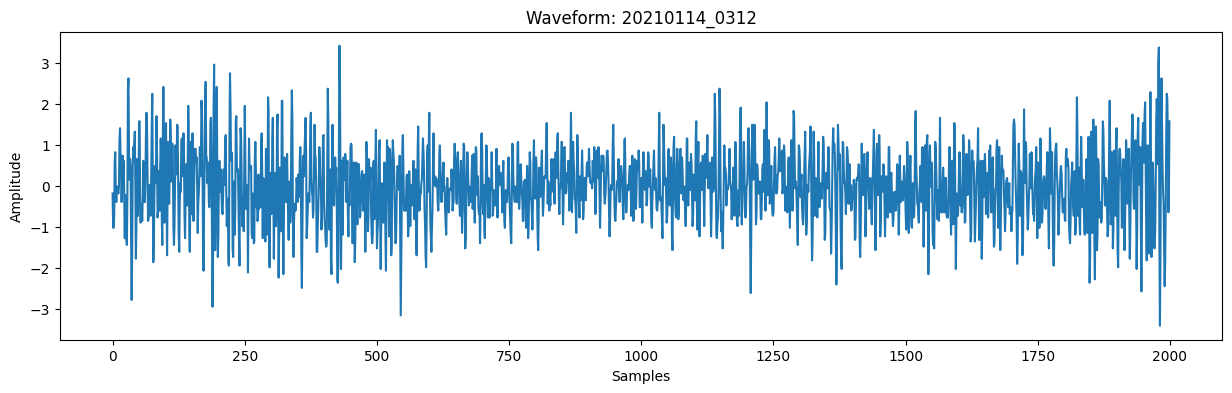

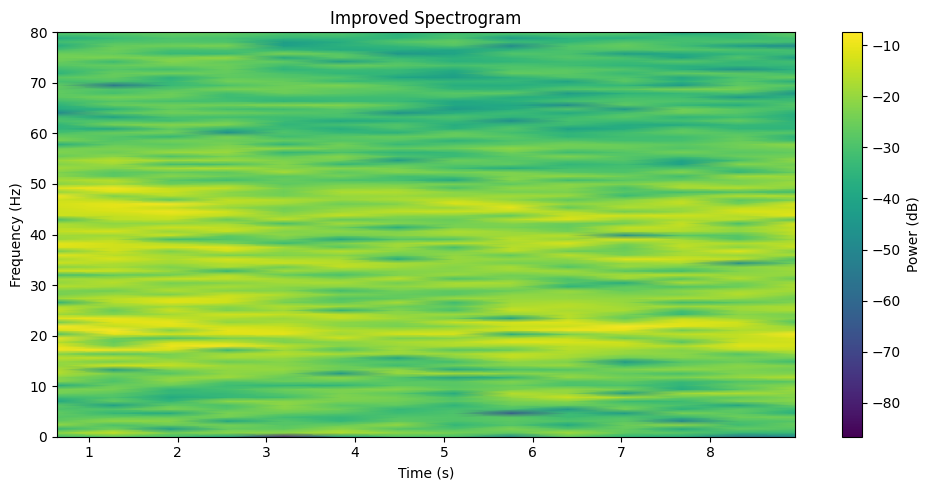



Event ID: 20210114_0635
File: D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2020_21\CS\DSMA.CS.EHZ_20210114_0632-20210114_0635.mseed
Prediction: Noise
Probabilities:
Noise 0.8595
Avalanche 0.0593
Earthquake 0.0812


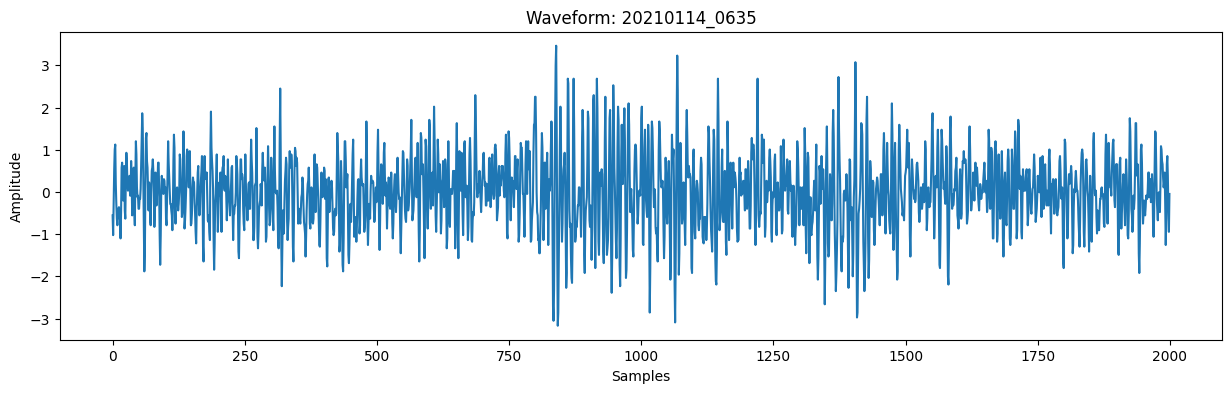

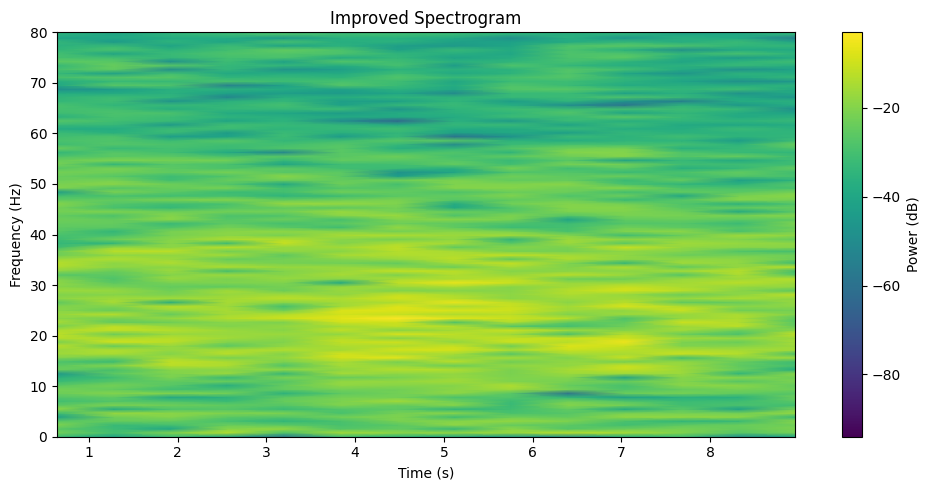



Event ID: 20220202_2339
File: D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2021_22\CS\DSMA.CS.EHZ_20220202_2339-20220202_2340.mseed
Prediction: Noise
Probabilities:
Noise 0.7494
Avalanche 0.0358
Earthquake 0.2148


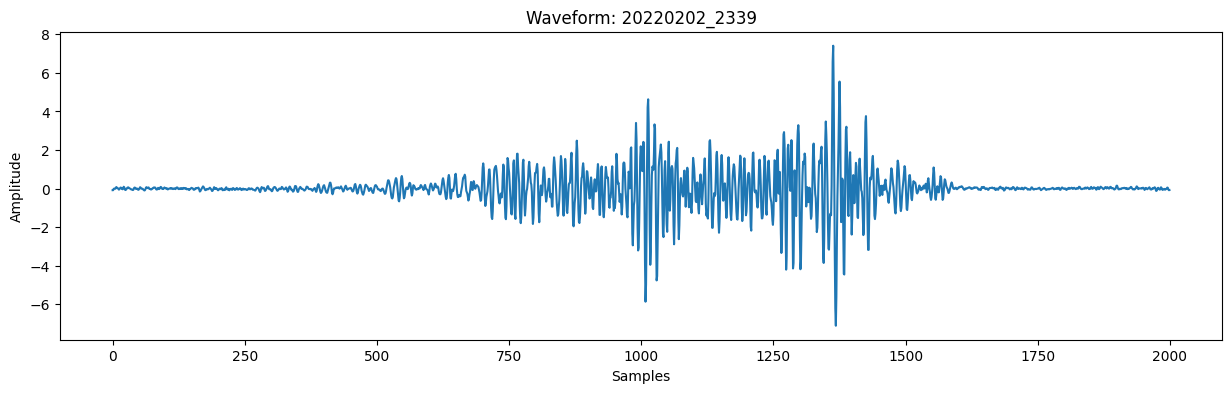

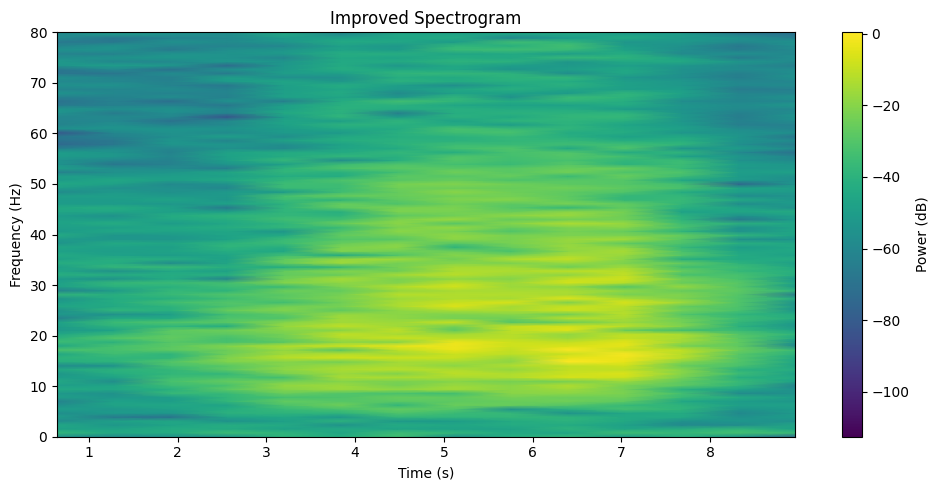



Event ID: 20220202_1825
File: D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2021_22\CS\DSMA.CS.EHZ_20220202_1825-20220202_1828.mseed
Prediction: Noise
Probabilities:
Noise 0.4973
Avalanche 0.4556
Earthquake 0.0471


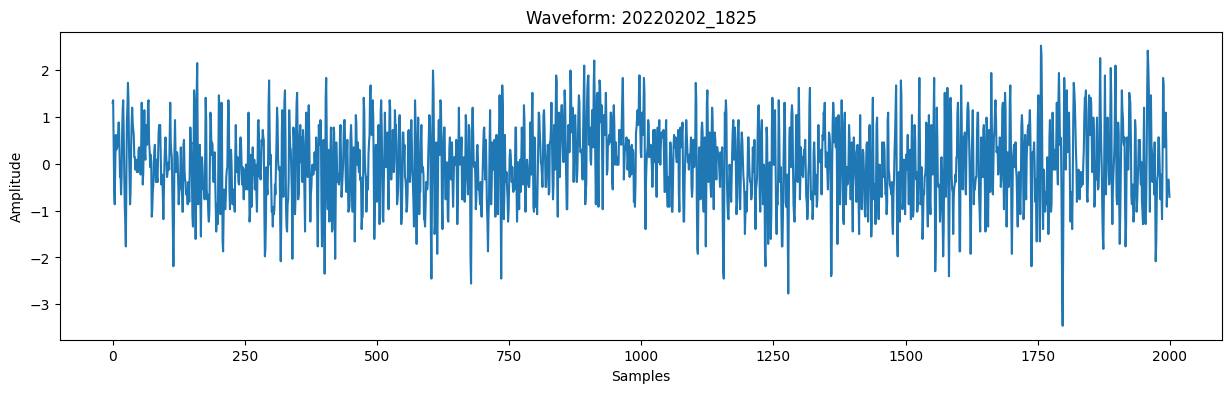

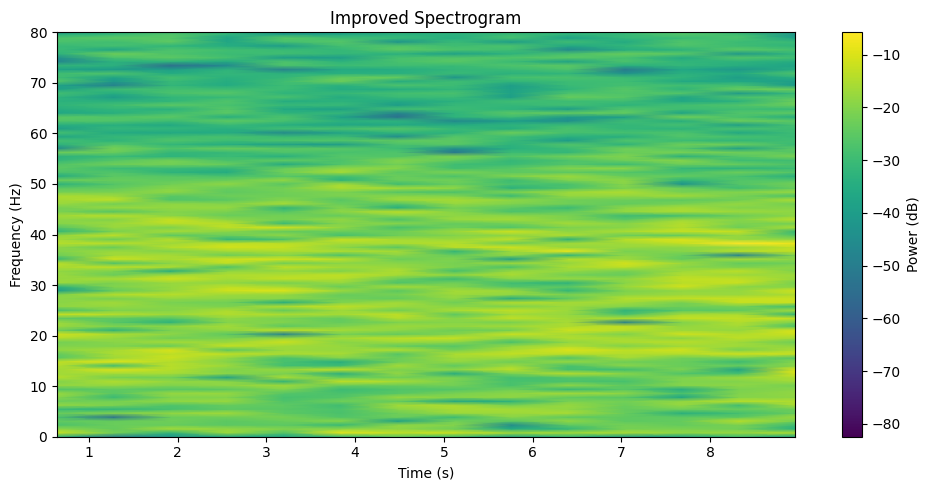



Event ID: 20220201_2308
File: D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2021_22\CS\DSMA.CS.EHZ_20220201_2308-20220201_2312.mseed
Prediction: Avalanche
Probabilities:
Noise 0.4515
Avalanche 0.5006
Earthquake 0.0478


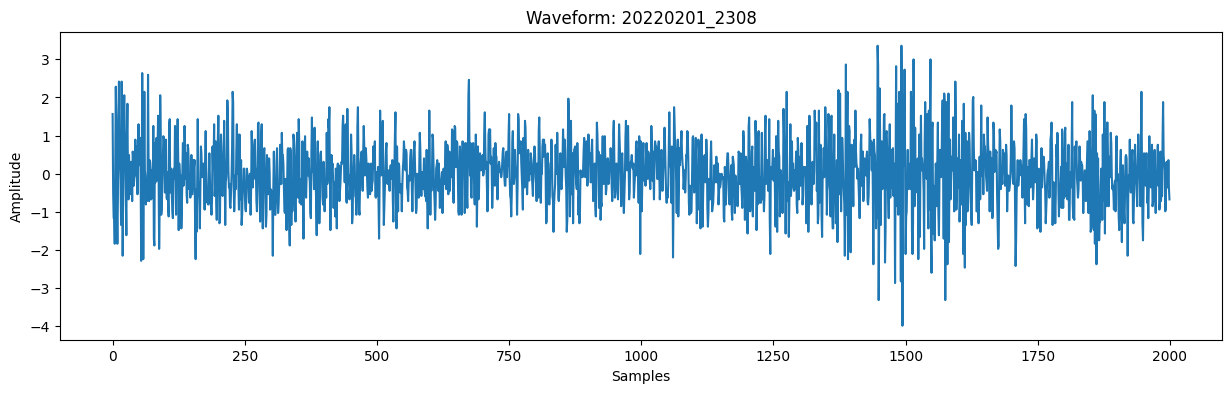

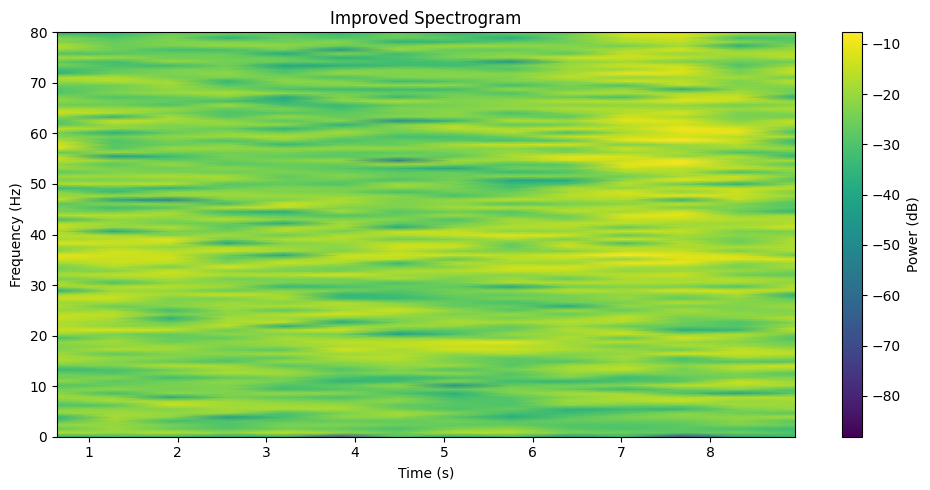



Event ID: 20220318_1504
File: D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2021_22\CS\DSMA.CS.EHZ_20220318_1504-20220318_1507.mseed
Prediction: Avalanche
Probabilities:
Noise 0.2429
Avalanche 0.7454
Earthquake 0.0117


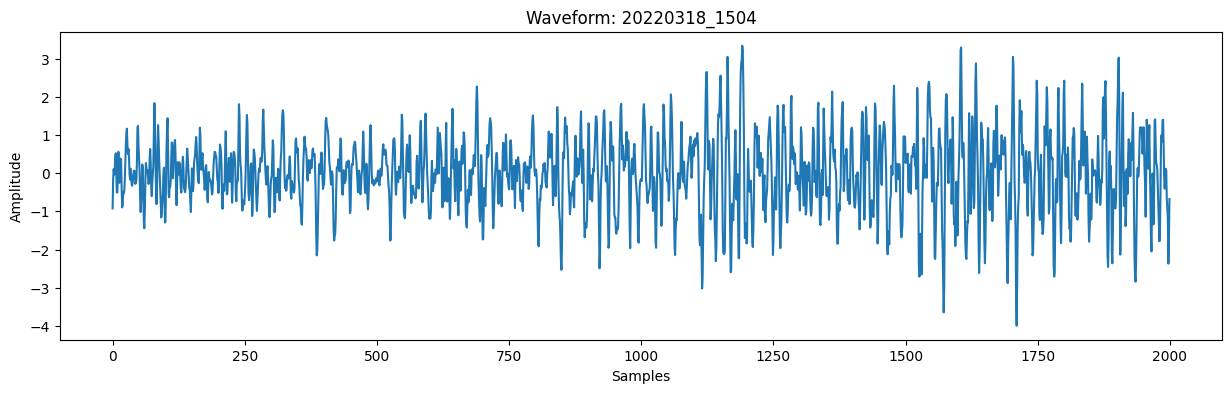

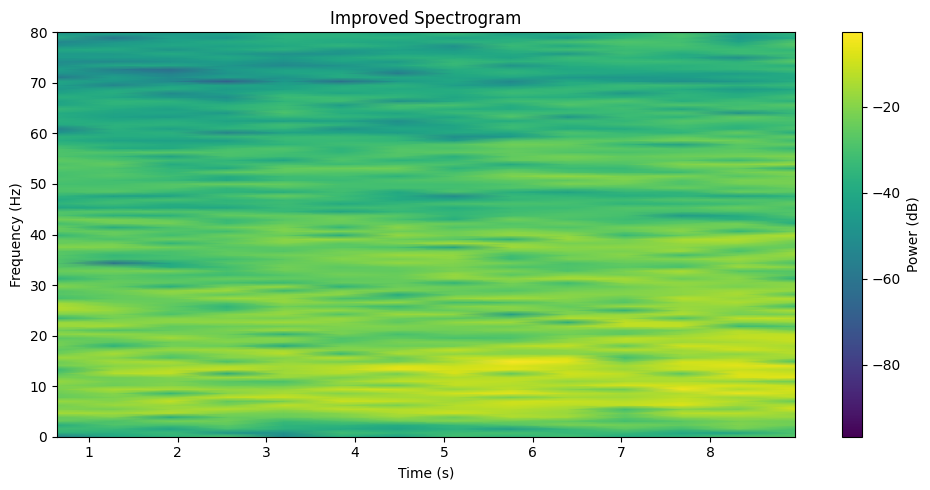



Event ID: 20220201_1558
File: D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2021_22\CS\DSMA.CS.EHZ_20220201_1558-20220201_1602.mseed
Prediction: Earthquake
Probabilities:
Noise 0.3316
Avalanche 0.0063
Earthquake 0.662


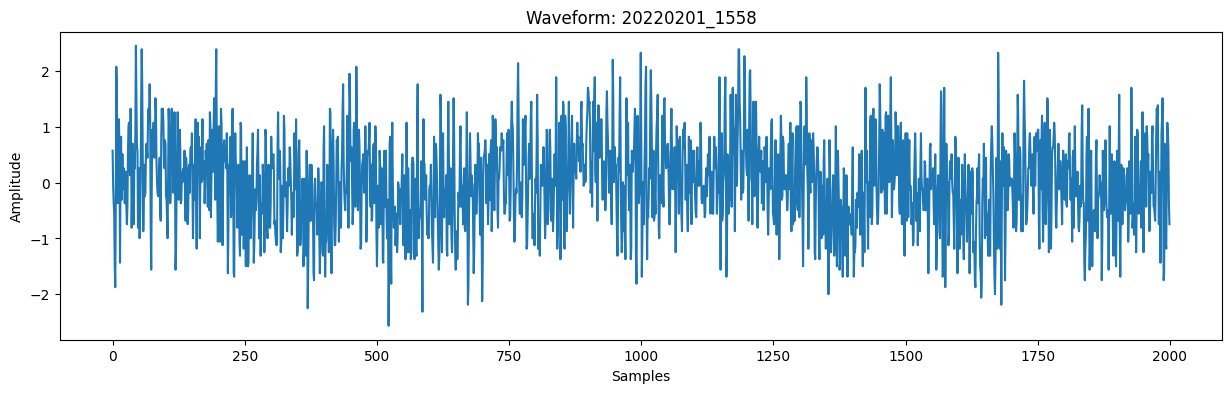

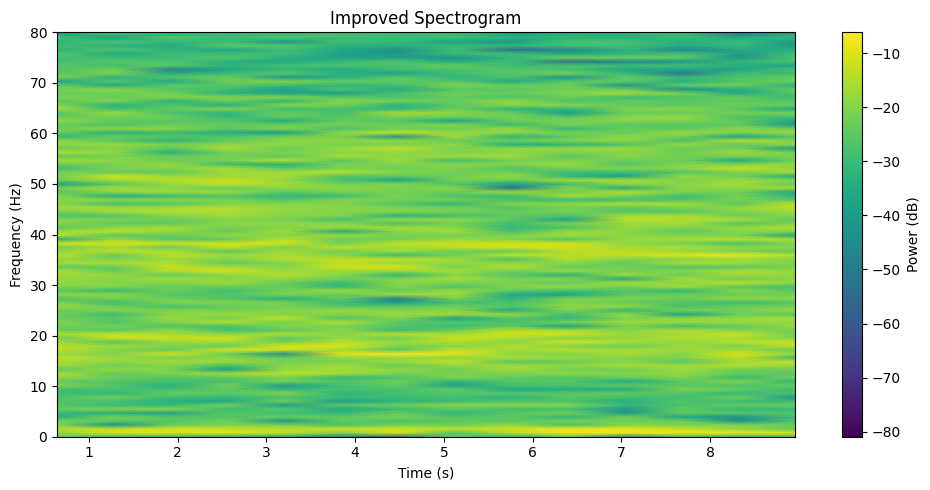



Event ID: 20210201_0838
File: D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2020_21\CS\DSMA.CS.EHZ_20210201_0838-20210201_0843.mseed
Prediction: Earthquake
Probabilities:
Noise 0.0946
Avalanche 0.0003
Earthquake 0.9051


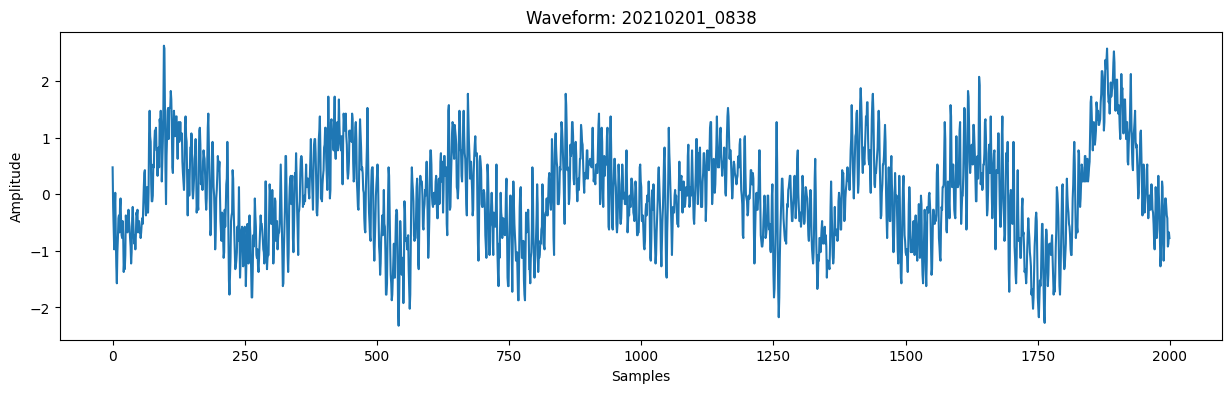

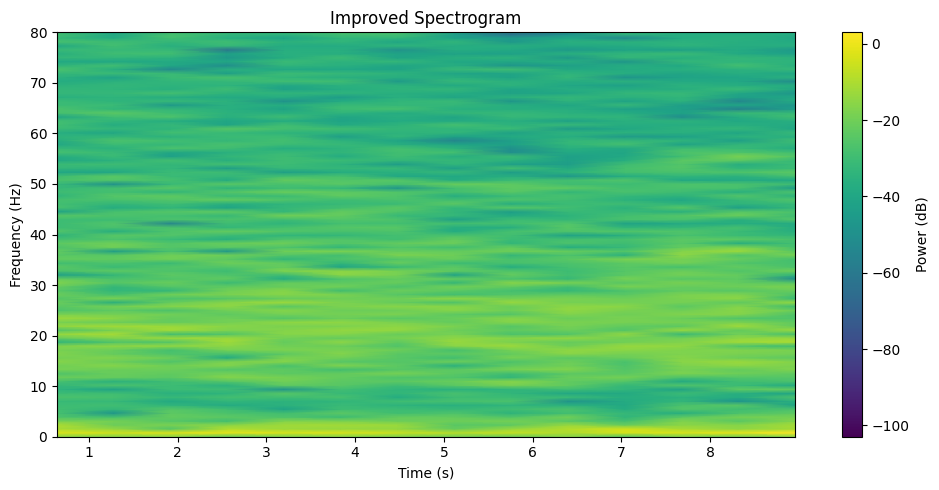



Event ID: 20220216_0437
File: D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2021_22\CS\DSMA.CS.EHZ_20220216_0437-20220216_0441.mseed
Prediction: Earthquake
Probabilities:
Noise 0.4356
Avalanche 0.0016
Earthquake 0.5628


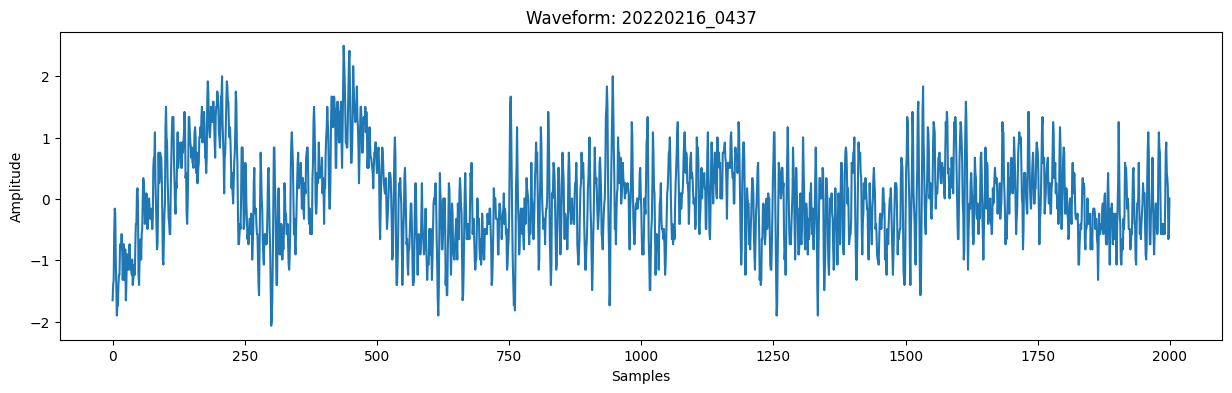

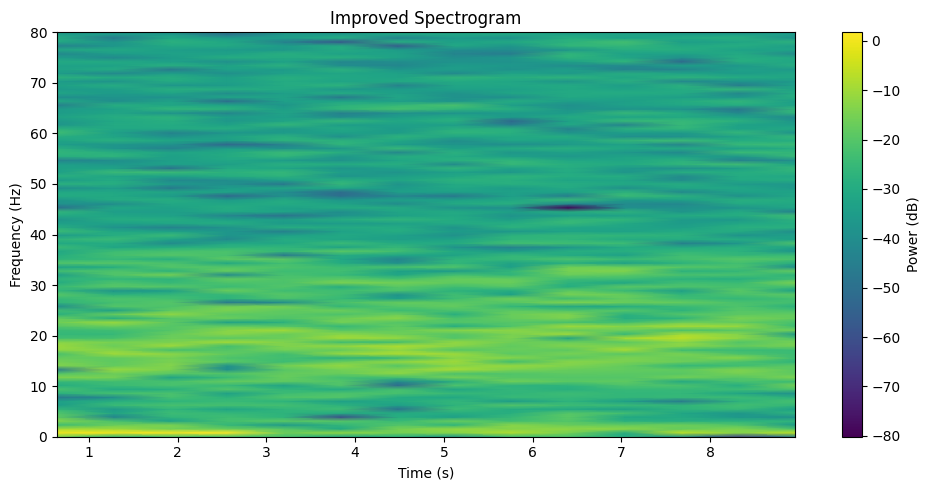

In [166]:
for event_id in test_events["Event_id"]:

    result = analyze_event(
        event_id,
        station="CS"
    )

    print("\n" + "="*60 + "\n")

In [169]:
sample_events = list(
    df.sample(20)["Event_id"]
)

results_df = analyze_multiple_events(
    sample_events
)

results_df

,Event_ID,Prediction,Noise_Prob,Avalanche_Prob,Earthquake_Prob,Actual_Label
0,20220331_1614,Earthquake,0.049528,0.000289,0.950183,2
1,20220112_1226,Earthquake,0.215955,0.009937,0.774108,2
2,20210129_0443,Noise,0.606640,0.014053,0.379307,0
3,20210512_1007,Noise,0.542898,0.047522,0.409580,2
4,20220402_1643,Earthquake,0.172710,0.001064,0.826226,0
5,20220202_1713,Noise,0.934722,0.041637,0.023641,0
6,20210125_1219,Noise,0.628190,0.009341,0.362469,2
7,20210130_0244,Earthquake,0.343363,0.007809,0.648828,2
8,20210126_0222,Noise,0.667927,0.036841,0.295232,0
9,20210125_0350,Noise,0.490465,0.022688,0.486847,0
